In [1]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_3_0.25_population_scale_one_pattern_20_replicates/output
analysis_path: validation_runs/validation_3_0.25_population_scale_one_pattern_20_replicates/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
# agg_clinical_episodes.tail(24)
agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
unit_id_to_inspect = 6
agg_clinical_episodes.loc[
    agg_clinical_episodes["unit_id"] == unit_id_to_inspect
].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
918,87,1,60507,60863,60887,60777,61181,61018,61081,NaN,...,61765,61153,61399,60780,61003,61202,61153,60937,60225,NaN
919,83,1,66613,66911,67287,67050,67042,66895,67149,NaN,...,67226,67554,67529,67396,67330,67132,67152,67398,66609,NaN
920,84,1,65197,65155,64976,64948,64809,65064,64945,NaN,...,65561,65726,65420,65139,65378,65073,65094,64906,64983,NaN
921,80,1,67056,66331,67157,67617,66681,67226,67071,NaN,...,66740,66709,66702,66942,66752,66789,67540,66781,66833,NaN
922,81,1,66712,66809,67522,67200,67107,67251,67193,NaN,...,66733,67071,67231,67334,67241,67342,67139,66574,66499,NaN
923,135,1,65323,65563,65506,65239,65890,64872,65189,NaN,...,65514,65748,65255,64799,65447,64730,65022,65367,65219,NaN
924,136,1,72323,72700,72288,72242,72625,72024,72268,NaN,...,72338,72113,72751,72411,72331,72431,71751,72097,72231,NaN
925,37,1,61194,61654,61170,61198,61408,60624,61610,NaN,...,61258,61735,61586,60923,61518,61272,61240,60722,61535,NaN
926,157,1,74226,74501,74817,74686,74285,74726,74389,NaN,...,74623,75147,74896,74162,73828,73960,74460,73882,74309,NaN
927,2,1,537567,537070,535664,536811,538061,537305,538577,537085.0,...,535495,536996,537471,537030,538108,536307,538750,534101,536948,537259.0


In [5]:
months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
end_month = int(months[-1]) + 1
start_month = end_month - 12

In [6]:
agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])

In [7]:
data_test = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes",
            "population",
            "treatments"
        ]    
    ].copy()

In [8]:
agg_test

,monthly_data_id,unit_id


In [9]:
data_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1356708,0
1,1,2,0,841223,0
2,1,3,0,689467,0
3,1,4,0,583546,0
4,1,5,0,998705,0
...,...,...,...,...,...
79,14,2,125290,838897,53755
80,14,3,89221,690506,47508
81,14,4,83604,586491,32406
82,14,5,103416,1000111,40561


In [10]:
agg_test = agg_test.merge(
    data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
    how="outer",
    on=["monthly_data_id", "unit_id"],
    suffixes=("", f"_{validation_replicates}"),
)

In [11]:
agg_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1356708,0
1,1,2,0,841223,0
2,1,3,0,689467,0
3,1,4,0,583546,0
4,1,5,0,998705,0
...,...,...,...,...,...
79,14,2,125290,838897,53755
80,14,3,89221,690506,47508
81,14,4,83604,586491,32406
82,14,5,103416,1000111,40561


In [12]:
agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()

In [13]:
g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [14]:
for unit_id, vals in g:
    print("unit_id:", unit_id)
    print(vals)
    print()

In [15]:
agg_test_at_calib_mean_by_location = pd.DataFrame()
agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [16]:
agg_test_at_calib_mean_by_location

,clinical_episodes_mean,population_mean,treatments_mean


In [17]:
agg_test_at_calib_mean_by_location.sum(axis=0)

clinical_episodes_mean    0.0
population_mean           0.0
treatments_mean           0.0
dtype: float64

In [18]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [19]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
936,157,1,74226,74501,74817,74686,74285,74726,74389,NaN,...,74623,75147,74896,74162,73828,73960,74460,73882,74309,NaN
937,157,2,45395,45402,45577,45039,45239,45195,45741,NaN,...,45086,45236,45483,45212,45256,45441,45208,45660,44985,NaN
938,157,3,37005,36956,37548,37532,37536,37260,37064,NaN,...,37177,37057,37579,36873,37220,37202,37289,36962,37156,NaN
939,157,4,30914,30951,30981,31183,30920,30632,30963,NaN,...,30880,30800,31285,31157,30994,30899,31196,30713,31059,NaN
940,157,5,62432,62475,62198,62268,61909,61975,62862,NaN,...,62469,62162,62211,62409,62165,62693,62084,62435,62174,NaN
941,157,6,36626,36691,37356,36927,36906,36573,36730,NaN,...,36685,37264,36696,37048,36476,37075,36537,36494,36416,NaN


In [20]:
data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
870,146,1,73224,73011,72965,73535,73069,73111,73533,NaN,...,73484,73178,74127,73029,73370,73142,73578,73474,72757,NaN
871,146,2,44818,44607,44610,44615,44926,44738,45136,NaN,...,44827,44672,44685,44647,45031,44420,44702,44967,44771,NaN
872,146,3,36418,36600,36516,36759,36652,36671,36668,NaN,...,36672,36562,36679,36826,36549,36685,36152,36556,36989,NaN
873,146,4,30554,30370,31107,30762,30590,30864,30628,NaN,...,30973,30632,30765,30753,30990,30734,30499,30868,30580,NaN
874,146,5,61546,61729,61831,61472,61382,60868,61737,NaN,...,61028,61739,62188,61563,61662,61258,61324,61383,61827,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,157,2,45395,45402,45577,45039,45239,45195,45741,NaN,...,45086,45236,45483,45212,45256,45441,45208,45660,44985,NaN
938,157,3,37005,36956,37548,37532,37536,37260,37064,NaN,...,37177,37057,37579,36873,37220,37202,37289,36962,37156,NaN
939,157,4,30914,30951,30981,31183,30920,30632,30963,NaN,...,30880,30800,31285,31157,30994,30899,31196,30713,31059,NaN
940,157,5,62432,62475,62198,62268,61909,61975,62862,NaN,...,62469,62162,62211,62409,62165,62693,62084,62435,62174,NaN


In [21]:
data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
data_at_calib_sum_1_year

,unit_id,monthly_data_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,1818,868103,866850,869575,872480,867443,870422,869883,0.0,...,868275,867857,876896,865561,868022,868834,870369,869586,865886,0.0
1,2,1818,530619,529661,528770,527371,530185,530236,529141,0.0,...,531215,530707,530609,528428,531382,529025,529358,532705,529503,0.0
2,3,1818,432825,433576,435031,435338,434241,433929,435111,0.0,...,436750,434437,435755,434108,435184,436006,434692,434996,433618,0.0
3,4,1818,361886,361530,364356,364259,363039,362991,361906,0.0,...,364427,362664,363566,364370,365313,362088,362775,364097,362649,0.0
4,5,1818,728991,730153,728626,726887,726531,725508,731599,0.0,...,727776,727291,728285,727575,726384,731559,727934,730126,730424,0.0
5,6,1818,428819,432375,429171,430650,428358,428627,430002,0.0,...,429610,429340,426551,430303,428904,432633,428154,427536,430609,0.0


In [22]:
data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
data_at_calib_mean_all_rep_1_year

0    745134.142857
1    454173.047619
2    372727.476190
3    311444.000000
4    624620.428571
5    368012.571429
dtype: float64

In [23]:
data_at_calib_mean_all_rep_1_year.sum()

np.float64(2876111.6666666665)

In [24]:
mean_treatment = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_treatment = mean_treatment.drop(columns=["monthly_data_id"])
# mean_treatment = mean_treatment.drop(columns=["clinical_episodes"])
mean_treatment["mean"] = mean_treatment.mean(axis=1)
mean_treatment["std"] = mean_treatment.std(axis=1)

mean_clinical_episodes = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_clinical_episodes = mean_clinical_episodes.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
mean_clinical_episodes["mean"] = mean_clinical_episodes.mean(axis=1)
mean_clinical_episodes["std"] = mean_clinical_episodes.std(axis=1)

mean_population = (
    agg_population.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_population = mean_population.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
mean_population["mean"] = mean_population.mean(axis=1)
mean_population["std"] = mean_population.std(axis=1)

mean_prevalence_2_to_10 = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["monthly_data_id"])
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
mean_prevalence_2_to_10["mean"] = mean_prevalence_2_to_10.mean(axis=1)
mean_prevalence_2_to_10["std"] = mean_prevalence_2_to_10.std(axis=1)

mean_prevalence_under_5 = (
    agg_prevalence_under_5.loc[
        agg_prevalence_under_5["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)

mean_clinical_episodes.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment.to_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population.to_csv(f"{analysis_path}/mean_population.csv")

In [25]:
mean_prevalence_2_to_10

,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,pfpr_2to10_9,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,28.668272,28.725842,28.713305,28.703525,28.719612,28.764093,28.707401,NaN,28.796002,28.792240,...,28.794938,28.609713,28.763171,28.761306,28.730896,28.791665,28.702572,NaN,28.736360,0.048174
2,30.999699,31.120331,30.979290,30.975683,31.083827,31.039437,30.992515,NaN,31.034719,30.952103,...,31.015402,31.065908,31.092018,31.007154,30.972574,31.026440,31.029083,NaN,31.025090,0.044843
3,25.381675,25.422507,25.319274,25.409644,25.339529,25.309665,25.433205,NaN,25.337318,25.481459,...,25.412043,25.384282,25.420489,25.357586,25.338325,25.297719,25.336562,NaN,25.374564,0.048954
4,28.650498,28.606703,28.584770,28.607195,28.531621,28.563093,28.593109,NaN,28.675020,28.658025,...,28.629503,28.623811,28.678599,28.562966,28.627123,28.647415,28.563031,NaN,28.614461,0.040454
5,18.963785,19.008161,18.975190,18.962947,18.911183,18.834907,18.983670,NaN,19.024220,18.991802,...,18.858928,18.962731,18.926815,19.032327,18.951768,18.973415,18.968174,NaN,18.957365,0.049043
6,27.838808,27.941431,27.791998,27.994413,27.788590,27.975734,27.973860,NaN,27.764602,27.814881,...,27.909848,27.902487,27.910000,27.938537,27.860469,27.814497,27.881990,NaN,27.880870,0.069817


In [26]:
mean_population

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1.656120e+06,1.655294e+06,1.656273e+06,1.655578e+06,1.655821e+06,1.655060e+06,1.656845e+06,NaN,1.656738e+06,1.655746e+06,...,1.657983e+06,1.655959e+06,1.655611e+06,1.655192e+06,1.656454e+06,1.655314e+06,1.654211e+06,NaN,1.656014e+06,872.940475
2,9.916080e+05,9.915956e+05,9.914797e+05,9.900732e+05,9.907858e+05,9.919405e+05,9.910635e+05,NaN,9.902533e+05,9.917638e+05,...,9.921406e+05,9.913852e+05,9.925861e+05,9.913079e+05,9.922258e+05,9.921340e+05,9.905871e+05,NaN,9.914399e+05,665.659349
3,8.392592e+05,8.395008e+05,8.396278e+05,8.384180e+05,8.392942e+05,8.384695e+05,8.390522e+05,NaN,8.392724e+05,8.386138e+05,...,8.392191e+05,8.380187e+05,8.389856e+05,8.398412e+05,8.386099e+05,8.391453e+05,8.403319e+05,NaN,8.391004e+05,565.343908
4,6.884561e+05,6.888655e+05,6.895048e+05,6.889489e+05,6.878524e+05,6.889720e+05,6.884443e+05,NaN,6.890152e+05,6.885802e+05,...,6.887069e+05,6.885807e+05,6.892352e+05,6.876985e+05,6.885438e+05,6.892749e+05,6.889071e+05,NaN,6.886488e+05,489.331441
5,1.202573e+06,1.203727e+06,1.204302e+06,1.201786e+06,1.204088e+06,1.202890e+06,1.203569e+06,NaN,1.202243e+06,1.203007e+06,...,1.202559e+06,1.203225e+06,1.202127e+06,1.202240e+06,1.202195e+06,1.202353e+06,1.203591e+06,NaN,1.203025e+06,820.486446
6,7.973745e+05,7.974764e+05,7.964198e+05,7.972986e+05,7.983363e+05,7.980869e+05,7.968736e+05,NaN,7.974995e+05,7.975002e+05,...,7.967154e+05,7.968728e+05,7.961238e+05,7.981493e+05,7.971540e+05,7.964081e+05,7.977424e+05,NaN,7.972921e+05,612.681473


In [27]:
mean_clinical_episodes

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,868103,866850,869575,872480,867443,870422,869883,0.0,871399,870375,...,876896,865561,868022,868834,870369,869586,865886,0.0,782390.8,260808.222042
2,530619,529661,528770,527371,530185,530236,529141,0.0,530228,528489,...,530609,528428,531382,529025,529358,532705,529503,0.0,476881.6,158964.847065
3,432825,433576,435031,435338,434241,433929,435111,0.0,434675,437002,...,435755,434108,435184,436006,434692,434996,433618,0.0,391363.7,130458.419617
4,361886,361530,364356,364259,363039,362991,361906,0.0,363926,364478,...,363566,364370,365313,362088,362775,364097,362649,0.0,327016.0,109010.092748
5,728991,730153,728626,726887,726531,725508,731599,0.0,731402,729973,...,728285,727575,726384,731559,727934,730126,730424,0.0,655851.2,218624.054157
6,428819,432375,429171,430650,428358,428627,430002,0.0,429011,427605,...,426551,430303,428904,432633,428154,427536,430609,0.0,386412.9,128812.517589


In [28]:
incidence_per_1000_sanity_check = mean_clinical_episodes["mean"] / mean_population["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1    472.454217
2    480.999003
3    466.408654
4    474.866114
5    545.168495
6    484.656615
Name: mean, dtype: float64

In [29]:
mean_treatment

,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,520916,521281,523370,525289,522479,523865,522576,0.0,523947,523682,...,527771,519996,522045,521842,522574,523009,519383,0.0,470369.70,156800.252557
2,258512,258627,257212,257411,259142,258549,257871,0.0,258907,257767,...,259073,257688,259570,258491,258042,259881,258977,0.0,232715.15,77574.954836
3,248067,248576,248975,249390,248895,248299,249213,0.0,249034,250367,...,249626,248920,248708,249479,248751,249173,248032,0.0,224087.50,74698.116635
4,156320,156057,157847,157434,156147,157140,156435,0.0,157281,157378,...,156990,156798,157417,156728,156759,157302,156840,0.0,141239.90,47082.391715
5,270468,271369,270177,269540,269877,269172,272367,0.0,271998,270862,...,269635,270491,269500,271833,270313,272305,270764,0.0,243552.80,81189.420129
6,162507,164985,162474,164158,162547,163486,163391,0.0,162840,162182,...,162526,164091,162658,164481,162851,162624,164229,0.0,146931.45,48983.065700


In [30]:
total_mean_clinical_episodes = mean_clinical_episodes["mean"].sum()
total_mean_treatment = mean_treatment["mean"].sum()
total_mean_population = mean_population["mean"].sum()

print(f"Total mean clinical episodes (all districts): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts): 3,019,916
Total mean treatments (all districts): 1,458,896
Total mean population (all districts): 6,175,520


In [31]:
mean_clinical_episodes = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population = pd.read_csv(f"{analysis_path}/mean_population.csv")

In [32]:
mean_prevalence_2_to_10

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,28.668272,28.725842,28.713305,28.703525,28.719612,28.764093,28.707401,NaN,28.796002,...,28.794938,28.609713,28.763171,28.761306,28.730896,28.791665,28.702572,NaN,28.736360,0.048174
1,2,30.999699,31.120331,30.979290,30.975683,31.083827,31.039437,30.992515,NaN,31.034719,...,31.015402,31.065908,31.092018,31.007154,30.972574,31.026440,31.029083,NaN,31.025090,0.044843
2,3,25.381675,25.422507,25.319274,25.409644,25.339529,25.309665,25.433205,NaN,25.337318,...,25.412043,25.384282,25.420489,25.357586,25.338325,25.297719,25.336562,NaN,25.374564,0.048954
3,4,28.650498,28.606703,28.584770,28.607195,28.531621,28.563093,28.593109,NaN,28.675020,...,28.629503,28.623811,28.678599,28.562966,28.627123,28.647415,28.563031,NaN,28.614461,0.040454
4,5,18.963785,19.008161,18.975190,18.962947,18.911183,18.834907,18.983670,NaN,19.024220,...,18.858928,18.962731,18.926815,19.032327,18.951768,18.973415,18.968174,NaN,18.957365,0.049043
5,6,27.838808,27.941431,27.791998,27.994413,27.788590,27.975734,27.973860,NaN,27.764602,...,27.909848,27.902487,27.910000,27.938537,27.860469,27.814497,27.881990,NaN,27.880870,0.069817


In [33]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [34]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_obs, prevalence_metadata = read_raster(pfpr_raster_path)
# observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Population_Per_District_{calibration_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_obs[prevalence_obs != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": mean_prevalence_2_to_10.unit_id, 
                                "mean_2_to_10_sim": mean_prevalence_2_to_10["mean"],
                                "mean_population_sim": mean_population["mean"],
                                "mean_clinical_episodes_sim": mean_clinical_episodes["mean"],
                                "mean_treatment_sim": mean_treatment["mean"],
                                })
data_sim["mean_2_to_10_sim"] = data_sim["mean_2_to_10_sim"].div(100)
data_sim["mean_population_sim"] = data_sim["mean_population_sim"] / country.population_scale
# Get total public and private from public cases and percentage private over public
data_sim["mean_clinical_episodes_sim"] = data_sim["mean_clinical_episodes_sim"] / country.population_scale
data_sim["mean_treatment_sim"] = (data_sim["mean_treatment_sim"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

In [35]:
data_sim

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim
0,7,0.287364,6.624056e+06,3129563.2,837258.066
1,9,0.310251,3.965760e+06,1907526.4,414232.967
2,11,0.253746,3.356402e+06,1565454.8,398875.750
3,26,0.286145,2.754595e+06,1308064.0,251407.022
4,32,0.189574,4.812099e+06,2623404.8,433523.984
5,35,0.278809,3.189168e+06,1545651.6,261537.981


In [36]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "mean_2_to_10_obs": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["mean_2_to_10_obs"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_population_per_district = observed_population_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_population_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and worldpop raster counts),Total Cases 2024 from projected population and observed incidence,mean_2_to_10_obs
0,7,0.287364,6.624056e+06,3129563.2,837258.066,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162
1,9,0.310251,3.965760e+06,1907526.4,414232.967,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528
2,11,0.253746,3.356402e+06,1565454.8,398875.750,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297
3,26,0.286145,2.754595e+06,1308064.0,251407.022,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176
4,32,0.189574,4.812099e+06,2623404.8,433523.984,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215
5,35,0.278809,3.189168e+06,1545651.6,261537.981,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542


In [37]:
compare_data.rename(columns={f"Population ({calibration_year} target based on worldometers birth rate and worldpop raster counts)": "population_obs"}, inplace=True)
compare_data.rename(columns={f"Total Cases {calibration_year} from projected population and observed incidence": "annual_clinical_episodes_obs"}, inplace=True)
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs
0,7,0.287364,6.624056e+06,3129563.2,837258.066,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162
1,9,0.310251,3.965760e+06,1907526.4,414232.967,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528
2,11,0.253746,3.356402e+06,1565454.8,398875.750,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297
3,26,0.286145,2.754595e+06,1308064.0,251407.022,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176
4,32,0.189574,4.812099e+06,2623404.8,433523.984,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215
5,35,0.278809,3.189168e+06,1545651.6,261537.981,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542


In [38]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_clinical_episodes_obs'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_obs'].sum():.0f}")

Total observed clinical episodes (all districts): 7771785
Total observed population (all districts): 26715437


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [39]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [40]:
compare_data["adjusted_mean_clinical_episodes_sim"] = compare_data["mean_clinical_episodes_sim"] * public_pct
compare_data[["adjusted_mean_clinical_episodes_sim", "mean_clinical_episodes_sim"]] 

,adjusted_mean_clinical_episodes_sim,mean_clinical_episodes_sim
0,1392655.624,3129563.2
1,848849.248,1907526.4
2,696627.386,1565454.8
3,582088.480,1308064.0
4,1167415.136,2623404.8
5,687814.962,1545651.6


In [41]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [42]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")
compare_data

,Unnamed: 0,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs,adjusted_mean_clinical_episodes_sim
0,0,7,0.287364,6.624056e+06,3129563.2,837258.066,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162,1392655.624
1,1,9,0.310251,3.965760e+06,1907526.4,414232.967,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528,848849.248
2,2,11,0.253746,3.356402e+06,1565454.8,398875.750,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297,696627.386
3,3,26,0.286145,2.754595e+06,1308064.0,251407.022,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176,582088.480
4,4,32,0.189574,4.812099e+06,2623404.8,433523.984,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215,1167415.136
5,5,35,0.278809,3.189168e+06,1545651.6,261537.981,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542,687814.962


In [43]:
# ======================================================
# Load data
# ======================================================
csv_path = f"{analysis_path}/compare_data_pfpr_pop_incidence.csv"
compare_data = pd.read_csv(csv_path)

# Optional style
# sns.set_style("whitegrid")

<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3702962/1739925926.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


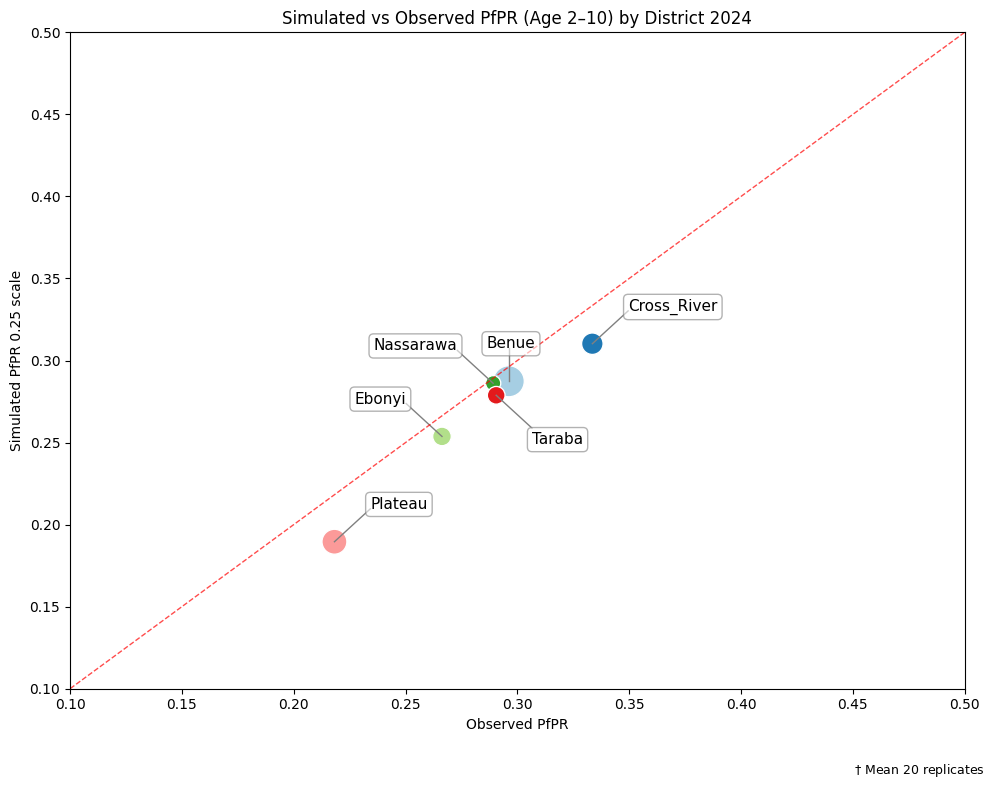

In [44]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["mean_2_to_10_obs", "mean_2_to_10_sim", "State", "mean_population_sim"]].dropna(
    subset=["mean_2_to_10_obs", "mean_2_to_10_sim"]
)

sns.scatterplot(
    data=d1,
    x="mean_2_to_10_obs",
    y="mean_2_to_10_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["mean_2_to_10_obs"].to_numpy(dtype=float)
y = d1["mean_2_to_10_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

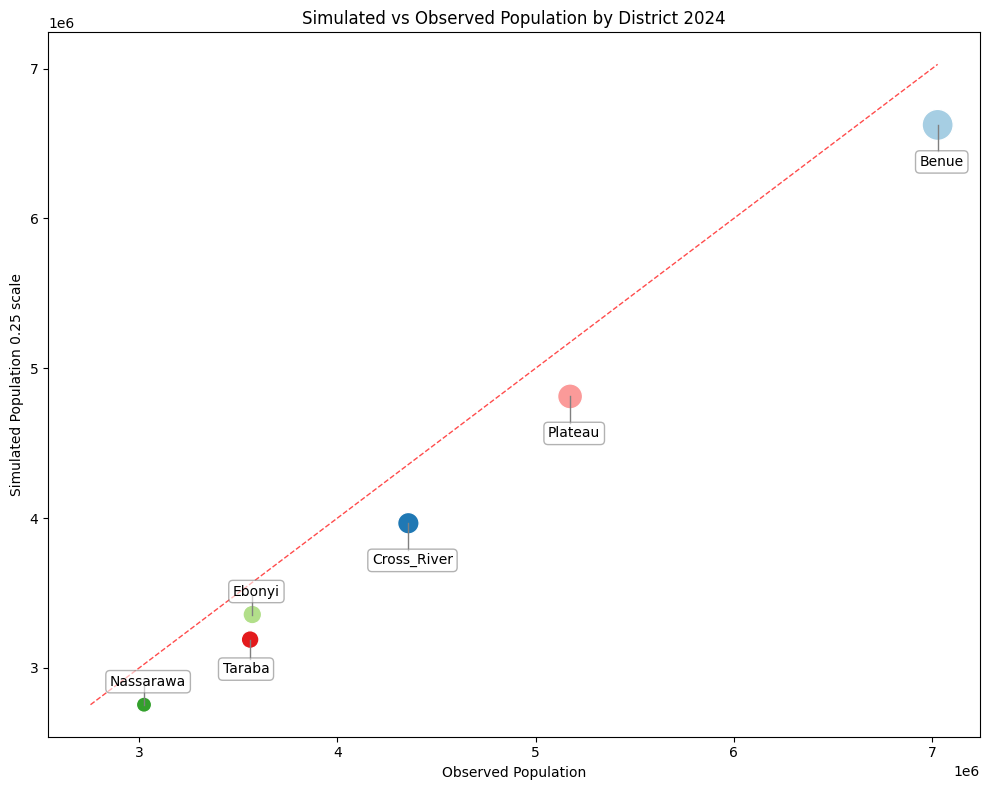

In [45]:
# ======================================================
# Figure 2: Simulated vs Observed Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_obs", "mean_population_sim", "State"]].dropna(
    subset=["population_obs", "mean_population_sim"]
)

sns.scatterplot(
    data=d2,
    x="population_obs",
    y="mean_population_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_obs"].to_numpy(dtype=float)
y = d2["mean_population_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_obs"].min(), d2["mean_population_sim"].min())
max_val = max(d2["population_obs"].max(), d2["mean_population_sim"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Observed Population by District {calibration_year}")
ax.set_xlabel("Observed Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

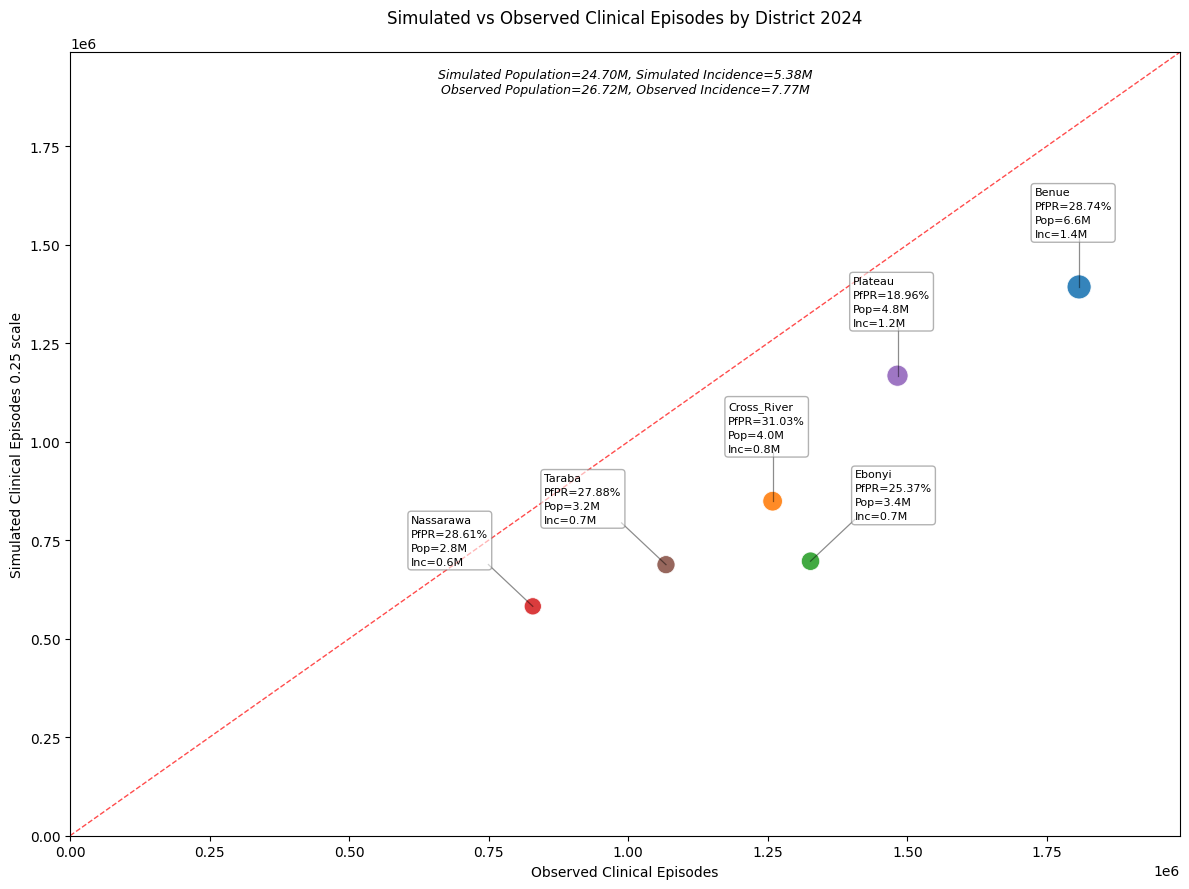

In [46]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "State",
        "mean_2_to_10_sim",
        "population_obs"
    ]
].dropna(
    subset=[
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "mean_2_to_10_sim",
        "population_obs"
    ]
).copy()

x = d4["annual_clinical_episodes_obs"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["adjusted_mean_clinical_episodes_sim"].to_numpy(float)

pop = d4["mean_population_sim"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["mean_population_sim"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["adjusted_mean_clinical_episodes_sim"].sum()
total_pop_obs = d4["population_obs"].sum()
total_clinical_episodes_obs = d4["annual_clinical_episodes_obs"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["mean_2_to_10_sim"]
    population = row["mean_population_sim"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["adjusted_mean_clinical_episodes_sim"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {calibration_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

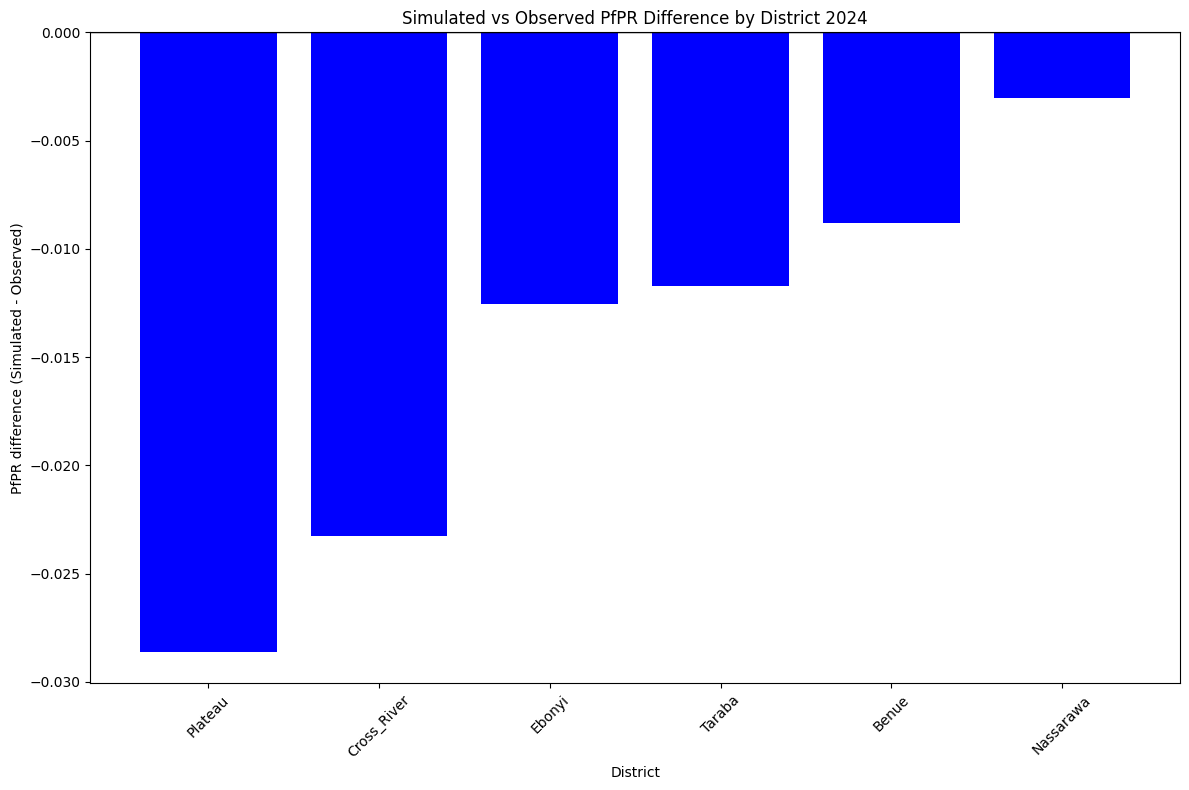

In [47]:
# ======================================================
# Figure 4: Simulated vs Observed PfPR difference by district
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8))

d3 = compare_data.copy()
d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
d3 = d3.sort_values("diff")

colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("District")
ax.set_ylabel("PfPR difference (Simulated - Observed)")
ax.set_title(f"Simulated vs Observed PfPR Difference by District {calibration_year}")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()